<a href="https://colab.research.google.com/github/nur21horin/machine_learning/blob/main/End_to_end_data_preprocessing1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [3]:
df=pd.read_csv("/content/insurance (1).csv")

In [4]:
print(df.head(5))

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [5]:
print("Last Five rows ....")
print(df.tail(5))

Last Five rows ....
      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603


In [6]:
print("Dataset Summuray: ")
print(df.info())

Dataset Summuray: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [10]:
print("Dataset Shape..")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset Shape..
Rows: 1338, Columns: 7


In [11]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [12]:
df.duplicated().sum()

np.int64(1)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
print(df.shape)

(1337, 7)


In [17]:
df['age']=df['age'].fillna(df['age'].median())
df['sex']=df['sex'].fillna(df['sex'].mode()[0])
df['bmi']=df['bmi'].fillna(df['bmi'].median())

print("\n Handling Outliers")
Q1=df['bmi'].quantile(0.25)
Q3=df['bmi'].quantile(0.75)

IQR=Q3-Q1
Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR

print("Outliers detecting ")
df['bmi']=np.where(df['bmi']>Upper_bound,Upper_bound,df['bmi'])
df['bmi']=np.where(df['bmi']<Lower_bound,Lower_bound,df['bmi'])
print("Outliers in 'bmi' have been capped")


 Handling Outliers
Outliers detecting 
Outliers in 'bmi' have been capped


In [21]:
print("Encoding categorical text columns")
le_sex=LabelEncoder()
le_smoker=LabelEncoder()
le_Region=LabelEncoder()

df['sex']=le_sex.fit_transform(df['sex'].astype(str))
df['smoker']=le_smoker.fit_transform(df['smoker'].astype(str))
df['region']=le_Region.fit_transform(df['region'].astype(str))

print("Encoding Done")

print(df[['sex','smoker','region']].head())

Encoding categorical text columns
Encoding Done
   sex  smoker  region
0    0       1       3
1    1       0       2
2    1       0       2
3    1       0       1
4    1       0       1


/tmp/ipykernel_4670/623649076.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=le_smoker.inverse_transform(df['smoker']),ax=axis[0,1],palette='pastel')


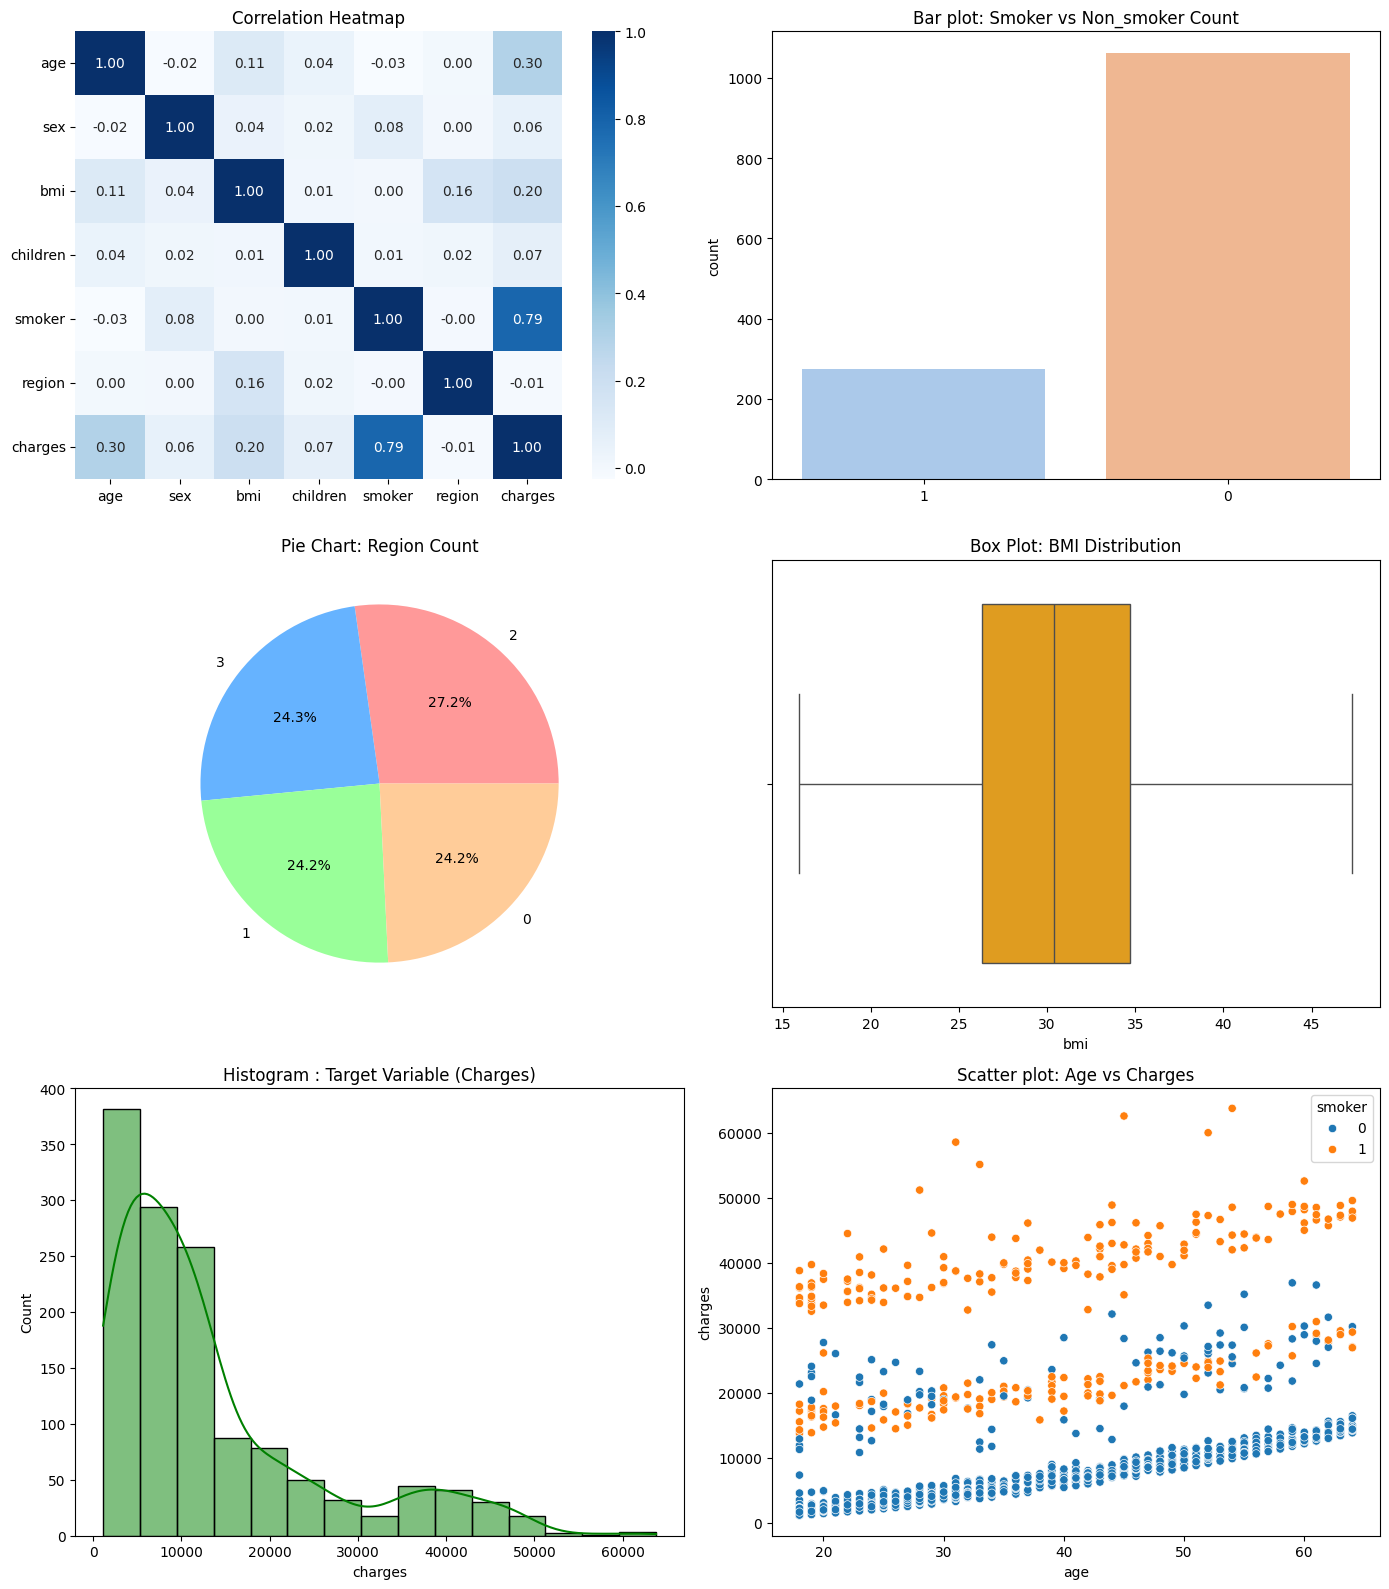

In [37]:
fig,axis=plt.subplots(3,2,figsize=(14,16))

#HeatMap
sns.heatmap(df.corr(),annot=True,cmap='Blues',fmt=".2f",ax=axis[0,0])
axis[0,0].set_title("Correlation Heatmap")

#Bar Plot
sns.countplot(x=le_smoker.inverse_transform(df['smoker']),ax=axis[0,1],palette='pastel')
axis[0,1].set_title("Bar plot: Smoker vs Non_smoker Count")

#Pie chart
region_counts=df['region'].value_counts()
axis[1,0].pie(region_counts,labels=le_Region.inverse_transform(region_counts.index),autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axis[1,0].set_title("Pie Chart: Region Count")

#Box plot
sns.boxplot(x=df['bmi'], ax=axis[1, 1], color='orange')
axis[1, 1].set_title('Box Plot: BMI Distribution')

#Histogram
sns.histplot(df['charges'],bins=15,kde=True,ax=axis[2,0],color='green')
axis[2,0].set_title("Histogram : Target Variable (Charges)")

#Scatterplot

sns.scatterplot(data=df,x='age',y='charges',hue='smoker',ax=axis[2,1])
axis[2,1].set_title("Scatter plot: Age vs Charges")

plt.tight_layout()
plt.show()


In [39]:
#liner regression

y=df['charges']
print("Running single linerregression")

x_single=df[['age']]
x_train_s,x_test_s,y_train_s,y_test_s=train_test_split(x_single,y,test_size=0.2,random_state=42)

single_model=LinearRegression()
single_model.fit(x_train_s,y_train_s)

y_pred_s=single_model.predict(x_test_s)

print("Mean Squared Error: ",mean_squared_error(y_test_s,y_pred_s))
print("R2 Score: ",r2_score(y_test_s,y_pred_s))

#Mmultiple LinerRegression

X_multi=df.drop('charges',axis=1)
X_train_m,X_test_m,y_train_m,y_test_m=train_test_split(X_multi,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_m=scaler.fit_transform(X_train_m)
X_test_m=scaler.transform(X_test_m)

multi_model=LinearRegression()
multi_model.fit(X_train_m,y_train_m)

y_pred_m=multi_model.predict(X_test_m)

print("\nMultiple LinerRegression")
print("Mean Squared Error: ",mean_squared_error(y_test_m,y_pred_m))
print("R2 Score: ",r2_score(y_test_m,y_pred_m))

Running single linerregression
Mean Squared Error:  166275348.23176482
R2 Score:  0.09513000782072023

Multiple LinerRegression
Mean Squared Error:  35467636.63842715
R2 Score:  0.8069852180198289


In [40]:
#model save
joblib.dump(multi_model,'insurance_lr_model.pkl')
joblib.dump(scaler,'insurance_scaler.pkl')

print("Saved ")

Saved 


In [41]:
import numpy as np
import pandas as pd
import joblib

In [42]:
# ==========================================
# STEP 2: LOAD THE SAVED MODEL & SCALER
# ==========================================
print("--- 2.1 Loading Saved Model and Scaler ---")
try:
    loaded_model = joblib.load('insurance_lr_model.pkl')
    loaded_scaler = joblib.load('insurance_scaler.pkl')
    print("Successfully loaded 'insurance_lr_model.pkl' and 'insurance_scaler.pkl'!")
except FileNotFoundError:
    print("Error: Please make sure 'insurance_lr_model.pkl' and 'insurance_scaler.pkl' are uploaded to your Colab files panel.")

--- 2.1 Loading Saved Model and Scaler ---
Successfully loaded 'insurance_lr_model.pkl' and 'insurance_scaler.pkl'!


In [43]:
# ==========================================
# STEP 3: DEFINE NEW VARIABLE DATA
# ==========================================
print("\n--- 3.1 Creating New Customer Data for Prediction ---")

# Let's create a DataFrame mimicking 3 brand new customers.
# Features MUST be in the exact same order as the training data:
# [age, sex, bmi, children, smoker, region]
# Note: Categorical features must use the same encoded numerical format:
# sex: female=0, male=1 | smoker: no=0, yes=1 | region: northwest=1, southeast=2, southwest=3, etc.

new_customers = pd.DataFrame([
    {
        'age': 25,
        'sex': 1,       # male
        'bmi': 24.2,    # Normal BMI
        'children': 0,
        'smoker': 0,    # Non-smoker
        'region': 3     # southwest
    },
    {
        'age': 45,
        'sex': 0,       # female
        'bmi': 36.5,    # High BMI (Obese range)
        'children': 2,
        'smoker': 1,    # Smoker
        'region': 2     # southeast
    },
    {
        'age': 62,
        'sex': 0,       # female
        'bmi': 28.1,    # Overweight BMI
        'children': 1,
        'smoker': 0,    # Non-smoker
        'region': 1     # northwest
    }
])

print("New customer input profiles:")
print(new_customers)


--- 3.1 Creating New Customer Data for Prediction ---
New customer input profiles:
   age  sex   bmi  children  smoker  region
0   25    1  24.2         0       0       3
1   45    0  36.5         2       1       2
2   62    0  28.1         1       0       1


In [44]:
# ==========================================
# STEP 4: PREPROCESS & SCALE NEW DATA
# ==========================================
print("\n--- 4.1 Scaling New Input Variables ---")
# Multiple Linear Regression relies heavily on the exact scale established during training.
# We use .transform() instead of .fit_transform() so we don't recalculate the weights.
new_customers_scaled = loaded_scaler.transform(new_customers)


--- 4.1 Scaling New Input Variables ---


In [45]:
# ==========================================
# STEP 5: PREDICT USING THE LOADED MODEL
# ==========================================
print("\n--- 5.1 Making Predictions ---")
predicted_charges = loaded_model.predict(new_customers_scaled)

# Add the predictions back into our dataframe for clear reporting
new_customers['Predicted_Charges ($)'] = np.round(predicted_charges, 2)

# Print final readable output
print("\n===========================================")
print("          FINAL PREDICTION RESULTS         ")
print("===========================================")
print(new_customers)


--- 5.1 Making Predictions ---

          FINAL PREDICTION RESULTS         
   age  sex   bmi  children  smoker  region  Predicted_Charges ($)
0   25    1  24.2         0       0       3                1918.43
1   45    0  36.5         2       1       2               35220.57
2   62    0  28.1         1       0       1               13438.47
